# Portfolio optimization: maximum Sharpe ratio

Reusable each FinSimCo quarter. Drop the new price file in `data/` and run `./run_quarter.sh Q2` (see `README.md`).

Method:
- Input: daily prices, one column per ticker, first column `Date`
- Missing prices filled with the previous row's value (forward fill)
- Simple daily returns, annualized with 252 trading days
- Sections 2 to 4: long-only, fully invested (weights between 0 and 1, sum to 1)
- Section 5: leverage up to `LEVERAGE` gross exposure (borrowing at the margin rate, or long/short with short rebate and borrow fee)
- Section 6: weight changes vs. the previous quarter, if it was run
- Section 7: trade plan in shares for `STRATEGY`, starting from the previous quarter's holdings
- Section 8: export to this quarter's workbook and to the master workbook with every quarter

All inputs are in the parameters cell below.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ---- Parameters: change these each quarter (or pass QUARTER / DATA_FILE as env vars) ----
QUARTER = os.environ.get("QUARTER", "Q1")
DATA_FILE = Path(os.environ.get("DATA_FILE", f"data/Historical Data {QUARTER}.xlsx"))

RF = 0.04             # annual risk-free rate
LEVERAGE = 2.0        # max gross exposure / capital
MARGIN_RATE = float(os.environ.get("MARGIN_RATE", RF))      # cost of borrowing cash (A and B)
SHORT_REBATE = RF     # interest earned on short sale proceeds
BORROW_FEE = 0.005    # annual fee to borrow shares (placeholder, use broker rate)
MAX_MISSING = 0.30    # drop a ticker if more than this share of its prices is missing

STRATEGY = os.environ.get("STRATEGY", "A")  # A = long-only levered (no shorts), B = long/short
INITIAL_CAPITAL = 100e6   # capital for the first quarter
NAV = float(os.environ["NAV"]) if os.environ.get("NAV") else None  # actual FinSimCo equity; None = estimate
MIN_POSITION = 10_000     # skip positions smaller than this (USD)
TRADING_COST = float(os.environ.get("TRADING_COST", 0.005))  # cost per $ traded (placeholder, use FinSimCo fee)
HOLD_LOSERS = os.environ.get("HOLD_LOSERS", "1") == "1"  # never sell a position below its cost basis
PERIODS = 4               # rebalances per year: a trading cost is earned back over one quarter
MASTER_FILE = Path("outputs/simulaciones_finsimco.xlsx")  # all quarters in one workbook
NEWS_FILE = Path("data/news.csv")

DAYS = 252
N_SIM = 50_000
SEED = 42
# -----------------------------------------------------------------------------------------

OUT = Path("outputs") / QUARTER
OUT.mkdir(parents=True, exist_ok=True)
np.random.seed(SEED)
print(f"Quarter: {QUARTER} | data: {DATA_FILE} | outputs: {OUT}/")

Quarter: Q2 | data: data/Historical Data Q2.xlsx | outputs: outputs/Q2/


## 1. Data and cleaning


In [2]:
assert DATA_FILE.exists(), f"Data file not found: {DATA_FILE}"
raw = pd.read_excel(DATA_FILE)
date_col = raw.columns[0]
raw[date_col] = pd.to_datetime(raw[date_col])
prices = raw.set_index(date_col).sort_index().apply(pd.to_numeric, errors="coerce")
prices = prices[~prices.index.duplicated(keep="last")].dropna(how="all", axis=1)

missing = prices.isna().mean()
dropped = missing[missing > MAX_MISSING]
if len(dropped):
    print("Dropped tickers (too much missing data):", dropped.round(2).to_dict())
prices = prices.drop(columns=dropped.index)

print("Missing before fill:", int(prices.isna().sum().sum()))
prices = prices.ffill().dropna()  # leading rows with no prior price are dropped
print("Missing after fill:", int(prices.isna().sum().sum()))
print(f"{prices.shape[1]} tickers, {len(prices)} days, {prices.index.min():%Y-%m-%d} to {prices.index.max():%Y-%m-%d}")
assert len(prices) > 60, "Too few rows after cleaning"
prices.head()

Missing before fill: 857
Missing after fill: 0
25 tickers, 272 days, 2025-12-18 to 2026-12-02


,AAPL,MSFT,2222.SR,GOOG,AMZN,NVDA,TSLA,BRK-B,META,TSM,...,LLY,JNJ,JPM,WMT,NVO,MA,AVGO,PG,005930.KS,ORCL
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-18,272.19,483.98,6.3855,303.75,226.76,174.14,483.37,503.39,664.45,284.68,...,1056.8800,208.31,313.00,114.83,47.61,566.21,329.88,145.52,86.08,180.03
2025-12-19,273.67,485.92,6.3855,308.61,227.35,180.99,481.20,494.53,658.77,288.95,...,1071.4399,206.37,317.21,114.36,48.09,572.23,340.36,144.46,85.04,191.97
2025-12-22,270.97,484.92,6.4125,311.33,228.43,183.69,488.73,499.95,661.50,293.28,...,1076.4800,207.32,323.09,112.60,48.10,575.70,341.45,142.69,88.40,198.38
2025-12-23,272.36,486.85,6.4152,315.68,232.14,189.21,485.56,500.51,664.94,296.95,...,1071.6400,205.78,325.93,110.90,51.61,576.35,349.32,143.18,89.20,195.34
2025-12-24,273.81,488.02,6.4125,315.67,232.38,188.61,485.40,501.34,667.55,298.80,...,1076.9800,207.78,329.17,111.61,52.56,579.45,350.22,144.49,88.88,197.49


In [3]:
returns = prices.pct_change().dropna()
mu = returns.mean() * DAYS
cov = returns.cov() * DAYS
vol = np.sqrt(np.diag(cov))
tickers = list(prices.columns)
n = len(tickers)

stats = pd.DataFrame(
    {"Annual return": mu, "Annual volatility": vol, "Sharpe": (mu - RF) / vol}
).sort_values("Sharpe", ascending=False)
stats.style.format("{:.2%}", subset=["Annual return", "Annual volatility"]).format(
    "{:.2f}", subset=["Sharpe"]
)

,Annual return,Annual volatility,Sharpe
JNJ,30.52%,18.70%,1.42
005930.KS,102.80%,75.58%,1.31
XOM,34.01%,24.71%,1.21
GOOG,28.18%,26.98%,0.90
AAPL,21.80%,23.44%,0.76
UNH,25.30%,32.71%,0.65
TSM,27.76%,36.81%,0.65
JPM,15.44%,19.87%,0.58
NVDA,15.38%,31.99%,0.36
AMZN,13.93%,30.59%,0.32


## 2. Monte Carlo simulation of random portfolios


In [4]:
def perf(w):
    r = w @ mu.values
    s = np.sqrt(w @ cov.values @ w)
    return r, s, (r - RF) / s


W = np.random.dirichlet(np.ones(n), N_SIM)
sim_ret = W @ mu.values
sim_vol = np.sqrt(np.einsum("ij,jk,ik->i", W, cov.values, W))
sim_sharpe = (sim_ret - RF) / sim_vol
best_sim = sim_sharpe.argmax()
print(
    f"Best simulated portfolio: return {sim_ret[best_sim]:.2%}, vol {sim_vol[best_sim]:.2%}, Sharpe {sim_sharpe[best_sim]:.2f}"
)

Best simulated portfolio: return 22.19%, vol 9.28%, Sharpe 1.96


## 3. Optimization (SLSQP)


In [5]:
bounds = [(0, 1)] * n
cons = ({"type": "eq", "fun": lambda w: w.sum() - 1},)
w0 = np.ones(n) / n

opt_sharpe = minimize(
    lambda w: -perf(w)[2], w0, method="SLSQP", bounds=bounds, constraints=cons
)
opt_minvar = minimize(
    lambda w: perf(w)[1], w0, method="SLSQP", bounds=bounds, constraints=cons
)
assert opt_sharpe.success and opt_minvar.success

w_sharpe, w_minvar = opt_sharpe.x, opt_minvar.x
summary = pd.DataFrame(
    {
        name: perf(w)
        for name, w in [
            ("Max Sharpe", w_sharpe),
            ("Min variance", w_minvar),
            ("Equal weight", w0),
        ]
    },
    index=["Return", "Volatility", "Sharpe"],
).T
summary.style.format("{:.2%}", subset=["Return", "Volatility"]).format(
    "{:.2f}", subset=["Sharpe"]
)

,Return,Volatility,Sharpe
Max Sharpe,33.95%,9.96%,3.01
Min variance,6.47%,6.16%,0.40
Equal weight,6.29%,10.53%,0.22


In [6]:
weights = pd.DataFrame(
    {"Max Sharpe": w_sharpe, "Min variance": w_minvar}, index=tickers
)
weights = weights[(weights > 1e-4).any(axis=1)].sort_values(
    "Max Sharpe", ascending=False
)
weights.style.format("{:.2%}")

,Max Sharpe,Min variance
JNJ,26.28%,3.93%
XOM,22.07%,9.73%
AAPL,15.39%,2.78%
GOOG,10.99%,0.00%
005930.KS,8.23%,2.82%
UNH,7.09%,1.50%
TSM,3.87%,1.53%
V,3.37%,2.22%
AMZN,1.42%,0.74%
JPM,1.17%,2.61%


## 4. Efficient frontier and capital market line


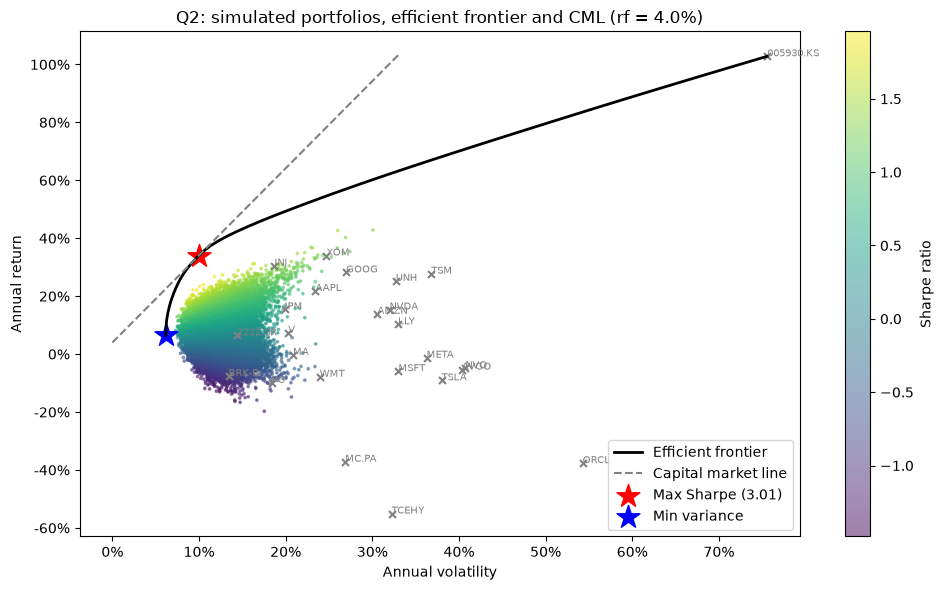

In [7]:
targets = np.linspace(perf(w_minvar)[0], mu.max(), 60)
frontier = []
for t in targets:
    c = cons + ({"type": "eq", "fun": lambda w, t=t: w @ mu.values - t},)
    r = minimize(lambda w: perf(w)[1], w0, method="SLSQP", bounds=bounds, constraints=c)
    frontier.append(r.fun if r.success else np.nan)

r_s, s_s, sh_s = perf(w_sharpe)
r_m, s_m, _ = perf(w_minvar)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(sim_vol, sim_ret, c=sim_sharpe, cmap="viridis", s=3, alpha=0.5)
plt.colorbar(sc, label="Sharpe ratio")
ax.plot(frontier, targets, color="black", lw=2, label="Efficient frontier")
x = np.linspace(0, max(sim_vol.max(), s_s) * 1.1, 50)
ax.plot(x, RF + sh_s * x, "--", color="gray", label="Capital market line")
ax.scatter(vol, mu, marker="x", color="gray", s=25)
for t, v, m in zip(tickers, vol, mu):
    ax.annotate(t, (v, m), fontsize=7, color="gray")
ax.scatter(s_s, r_s, marker="*", color="red", s=300, label=f"Max Sharpe ({sh_s:.2f})")
ax.scatter(s_m, r_m, marker="*", color="blue", s=300, label="Min variance")
ax.set_xlabel("Annual volatility")
ax.set_ylabel("Annual return")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title(f"{QUARTER}: simulated portfolios, efficient frontier and CML (rf = {RF:.1%})")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(OUT / "frontier.png", dpi=150)
plt.show()

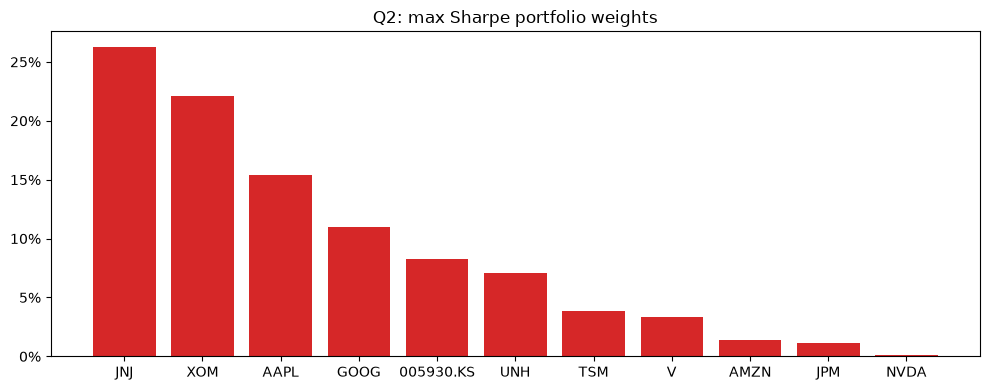

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ws = weights["Max Sharpe"][weights["Max Sharpe"] > 1e-4]
ax.bar(ws.index, ws.values, color="tab:red")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title(f"{QUARTER}: max Sharpe portfolio weights")
plt.tight_layout()
fig.savefig(OUT / "weights_max_sharpe.png", dpi=150)
plt.show()

## 5. Leverage (hedge fund)

Two ways to use leverage, both capped at a gross exposure of `LEVERAGE` times capital:

- **A. Borrow at the risk-free rate and lever the max Sharpe portfolio.** Return and volatility scale up together along the CML, so the **Sharpe ratio does not change**.
- **B. Long/short.** Net exposure 100%, gross exposure up to `LEVERAGE`. This widens the opportunity set, so the **Sharpe ratio can rise**.

Financing for B, per year:

- Longs above 100% of capital are bought on margin at `MARGIN_RATE`.
- Short sale proceeds stay with the broker as collateral and earn `SHORT_REBATE`.
- Each short pays `BORROW_FEE` on its value to the stock lender.

So B's return = expected stock returns + short × `SHORT_REBATE` − (long − 100%) × `MARGIN_RATE` − short × `BORROW_FEE`.
The optimizer includes these costs, so a higher fee leads to fewer shorts.

Not modeled: margin calls, hard-to-borrow stocks with higher fees, a spread on margin above the risk-free rate.


In [9]:
# A. Levered tangency portfolio: L in max Sharpe, (1 - L) in cash (negative = borrowing)
lev_ret = MARGIN_RATE + LEVERAGE * (r_s - MARGIN_RATE)
lev_vol = LEVERAGE * s_s
w_lev = LEVERAGE * w_sharpe


# B. Long/short max Sharpe: w = long - short, sum(w) = 1, sum(long + short) <= LEVERAGE
def split(x):
    return x[:n] - x[n:]


def carry(x, rebate, margin, fee):
    long_, short = x[:n].sum(), x[n:].sum()
    return short * rebate - max(long_ - 1, 0) * margin - short * fee


def perf_ls(x, rebate=SHORT_REBATE, margin=MARGIN_RATE, fee=BORROW_FEE):
    r, s, _ = perf(split(x))
    r += carry(x, rebate, margin, fee)
    return r, s, (r - RF) / s


def opt_long_short(**kw):
    cons = (
        {"type": "eq", "fun": lambda x: split(x).sum() - 1},
        {"type": "ineq", "fun": lambda x: LEVERAGE - x.sum()},
    )
    x0 = np.concatenate([w0, np.zeros(n)])
    res = minimize(
        lambda x: -perf_ls(x, **kw)[2],
        x0,
        method="SLSQP",
        bounds=[(0, LEVERAGE)] * (2 * n),
        constraints=cons,
        options={"maxiter": 1000},
    )
    assert res.success, res.message
    x = res.x.copy()
    x[x < 1e-6] = 0
    return x


x_ls0 = opt_long_short(
    rebate=0, margin=0, fee=0
)  # previous version: no financing at all
x_ls = opt_long_short()  # with rebate, margin and borrow fee
w_ls0, w_ls = split(x_ls0), split(x_ls)


def row(r, s, w, borrow=0.0):
    return {
        "Return": r,
        "Volatility": s,
        "Sharpe": (r - RF) / s,
        "Long": w[w > 0].sum(),
        "Short": -w[w < 0].sum(),
        "Gross": np.abs(w).sum(),
        "Borrowed": borrow,
    }


lev_summary = pd.DataFrame(
    {
        "Max Sharpe (no leverage)": row(r_s, s_s, w_sharpe),
        f"A. Levered max Sharpe ({LEVERAGE:.0f}x)": row(
            lev_ret, lev_vol, w_lev, borrow=LEVERAGE - 1
        ),
        "B. Long/short, no financing": row(
            *perf_ls(x_ls0, 0, 0, 0)[:2],
            w_ls0,
            borrow=max(w_ls0[w_ls0 > 0].sum() - 1, 0),
        ),
        f"B. Long/short, rebate + {BORROW_FEE:.1%} fee": row(
            *perf_ls(x_ls)[:2], w_ls, borrow=max(w_ls[w_ls > 0].sum() - 1, 0)
        ),
    }
).T
lev_summary.style.format(
    "{:.2%}", subset=["Return", "Volatility", "Long", "Short", "Gross", "Borrowed"]
).format("{:.2f}", subset=["Sharpe"])

,Return,Volatility,Sharpe,Long,Short,Gross,Borrowed
Max Sharpe (no leverage),33.95%,9.96%,3.01,100.00%,-0.00%,100.00%,0.00%
A. Levered max Sharpe (2x),63.61%,19.92%,2.99,200.00%,-0.00%,200.00%,100.00%
"B. Long/short, no financing",59.77%,12.59%,4.43,150.00%,50.00%,200.00%,50.00%
"B. Long/short, rebate + 0.5% fee",59.62%,12.64%,4.40,150.00%,50.00%,200.00%,50.00%


In [10]:
lev_weights = pd.DataFrame(
    {
        "Max Sharpe": w_sharpe,
        f"A. Levered {LEVERAGE:.0f}x": w_lev,
        "B. No financing": w_ls0,
        "B. Rebate + fee": w_ls,
    },
    index=tickers,
)
lev_weights = lev_weights[(lev_weights.abs() > 1e-4).any(axis=1)].sort_values(
    "B. Rebate + fee", ascending=False
)
lev_weights.style.format("{:.2%}")

,Max Sharpe,A. Levered 2x,B. No financing,B. Rebate + fee
JNJ,26.28%,52.56%,29.70%,29.76%
AAPL,15.39%,30.79%,23.07%,23.18%
XOM,22.07%,44.15%,22.40%,22.48%
GOOG,10.99%,21.99%,19.30%,19.42%
UNH,7.09%,14.18%,9.19%,9.21%
005930.KS,8.23%,16.46%,8.24%,8.29%
TSM,3.87%,7.73%,7.82%,7.82%
2222.SR,0.00%,0.00%,6.90%,6.65%
JPM,1.17%,2.34%,5.35%,5.30%
MSFT,0.00%,0.00%,5.26%,5.23%


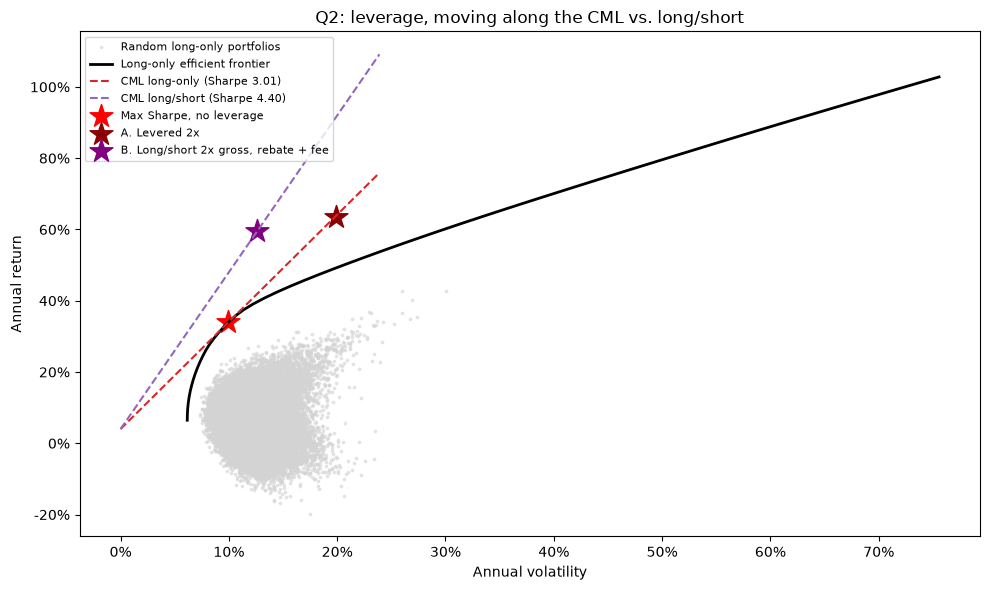

In [11]:
r_ls, s_ls, sh_ls = perf_ls(x_ls)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    sim_vol, sim_ret, c="lightgray", s=3, alpha=0.5, label="Random long-only portfolios"
)
ax.plot(frontier, targets, color="black", lw=2, label="Long-only efficient frontier")
x = np.linspace(0, max(lev_vol, s_ls) * 1.2, 50)
ax.plot(
    x, RF + sh_s * x, "--", color="tab:red", label=f"CML long-only (Sharpe {sh_s:.2f})"
)
ax.plot(
    x,
    RF + sh_ls * x,
    "--",
    color="tab:purple",
    label=f"CML long/short (Sharpe {sh_ls:.2f})",
)
ax.scatter(s_s, r_s, marker="*", color="red", s=300, label="Max Sharpe, no leverage")
ax.scatter(
    lev_vol,
    lev_ret,
    marker="*",
    color="darkred",
    s=300,
    label=f"A. Levered {LEVERAGE:.0f}x",
)
ax.scatter(
    s_ls,
    r_ls,
    marker="*",
    color="purple",
    s=300,
    label=f"B. Long/short {LEVERAGE:.0f}x gross, rebate + fee",
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Annual volatility")
ax.set_ylabel("Annual return")
ax.set_title(f"{QUARTER}: leverage, moving along the CML vs. long/short")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
fig.savefig(OUT / "leverage.png", dpi=150)
plt.show()

## 6. Changes vs. previous quarter

Trades needed to move from last quarter's weights to this quarter's. Skipped if the previous quarter has not been run.

In [12]:
prev_q = f"Q{int(QUARTER[1:]) - 1}" if QUARTER[1:].isdigit() and int(QUARTER[1:]) > 1 else None
prev_file = Path("outputs") / str(prev_q) / f"resultados_sharpe_{prev_q}.xlsx"
if prev_q and prev_file.exists():
    prev_w = pd.read_excel(prev_file, sheet_name="Leverage weights", index_col=0)
    cur_w = pd.DataFrame({"Max Sharpe": w_sharpe, "A. Levered": w_lev, "B. Rebate + fee": w_ls}, index=tickers)
    cols = ["Max Sharpe", "A. Levered", "B. Rebate + fee"]
    change = cur_w[cols].sub(prev_w.reindex(columns=cols), fill_value=0).fillna(0)
    change = change[(change.abs() > 1e-4).any(axis=1)].sort_values("B. Rebate + fee")
    print(f"Weight change {prev_q} -> {QUARTER} (positive = buy, negative = sell)")
    display(change.style.format("{:+.2%}"))
else:
    change = None
    print(f"No previous quarter results found ({prev_file}), skipping comparison")

Weight change Q1 -> Q2 (positive = buy, negative = sell)


,Max Sharpe,A. Levered,B. Rebate + fee
2222.SR,-11.35%,-22.70%,-9.01%
LLY,-2.76%,-5.53%,-7.30%
MC.PA,-0.00%,-0.00%,-7.15%
TSM,-2.68%,-5.37%,-4.35%
BRK-B,-0.00%,-0.00%,-4.28%
TCEHY,-0.00%,-0.00%,-2.96%
MSFT,-3.03%,-6.07%,-2.88%
005930.KS,-0.68%,-1.36%,-1.59%
ORCL,-0.00%,-0.00%,-1.45%
V,+0.56%,+1.11%,-0.70%


## 7. Trade plan (shares)

Target positions for `STRATEGY` on the current equity, priced at the last price in the file, rounded down to whole shares.

Equity: the `NAV` env var if given (use FinSimCo's actual figure). Otherwise, for Q1 `INITIAL_CAPITAL`; for later quarters, last quarter's shares at today's prices, minus the margin loan and its interest.

From Q2 on (strategy A), the target is optimized **knowing current holdings**: maximize Sharpe net of `TRADING_COST` on every dollar traded. A stock is only bought or sold if the Sharpe gain pays for the trade. `TRADING_COST=0` gives the from-scratch portfolio.

With `HOLD_LOSERS` on, a position trading below its cost basis is never sold (it can still be added to). Winners can be trimmed, which takes profit.

In [13]:
last_px = prices.iloc[-1]
end_date = prices.index.max()
target_w = pd.Series(w_lev if STRATEGY == "A" else w_ls, index=tickers)

prev_pos, prev_cost, prev_loan, prev_end = pd.Series(dtype=float), pd.Series(dtype=float), 0.0, None
if prev_q and prev_file.exists():
    prev_xl = pd.read_excel(prev_file, sheet_name=None, index_col=0)
    if "Positions" in prev_xl:
        prev_pos = prev_xl["Positions"]["Shares"]
        prev_cost = prev_xl["Positions"]["Cost basis"] if "Cost basis" in prev_xl["Positions"] else prev_xl["Positions"]["Price"]
        prev_loan = float(prev_xl["Parameters"].loc["Margin loan", "Value"])
        prev_end = pd.Timestamp(prev_xl["Parameters"].loc["End", "Value"])

# prices for every ticker held or targeted (a dropped ticker falls back to its last raw price)
px = raw.set_index(date_col).sort_index().apply(pd.to_numeric, errors="coerce").ffill().iloc[-1]
px = px.reindex(prev_pos.index.union(target_w.index))

if NAV is not None:
    capital, capital_src = NAV, "NAV from FinSimCo"
elif len(prev_pos):
    days = (end_date - prev_end).days
    interest = prev_loan * MARGIN_RATE * days / 365
    capital = float((prev_pos * px[prev_pos.index]).sum()) - prev_loan - interest
    capital_src = f"Estimate: {prev_q} shares at today's prices - loan - {days} days interest (${interest:,.0f})"
else:
    capital, capital_src = INITIAL_CAPITAL, "Initial capital"

# Optimize knowing current holdings: max Sharpe net of the cost of trading away from them.
# w = w_prev + buys - sells; cost = TRADING_COST * turnover, annualized over one quarter's holding.
method = "Max Sharpe from scratch"
if STRATEGY == "A" and len(prev_pos) and TRADING_COST > 0:
    w_prev = (prev_pos * px[prev_pos.index] / capital).reindex(tickers).fillna(0).values

    def unpack(x):
        return w_prev + x[:n] - x[n:]

    def neg_net_sharpe(x):
        w = unpack(x)
        r = w @ mu.values - (w.sum() - 1) * MARGIN_RATE - TRADING_COST * x.sum() * PERIODS
        return -(r - RF) / np.sqrt(w @ cov.values @ w)

    # losers (price below cost basis) can be bought but not sold
    losers = [t for t in tickers if HOLD_LOSERS and prev_pos.get(t, 0) > 0 and px[t] < prev_cost[t]]
    sell_bounds = [(0, 0) if t in losers else (0, None) for t in tickers]
    if losers:
        print("Held, below cost basis (no sells):", ", ".join(losers))
    res = minimize(neg_net_sharpe, np.zeros(2 * n), method="SLSQP", bounds=[(0, None)] * n + sell_bounds,
                   constraints=[{"type": "eq", "fun": lambda x: unpack(x).sum() - LEVERAGE},
                                {"type": "ineq", "fun": unpack}], options={"maxiter": 2000})
    assert res.success, res.message
    target_w = pd.Series(np.clip(unpack(res.x), 0, None), index=tickers)
    method = f"Max Sharpe net of {TRADING_COST:.2%} trading cost from {prev_q} holdings"
    r_n, s_n, _ = perf(target_w.values / LEVERAGE)
    print(f"{method}: turnover {res.x.sum():.1%} of equity (from scratch: {np.abs(pd.Series(w_lev, index=tickers).values - w_prev).sum():.1%})")
    print(f"Expected (levered, before costs): return {RF + LEVERAGE * (r_n - RF):.2%}, vol {LEVERAGE * s_n:.2%}, Sharpe {(r_n - RF) / s_n:.2f} vs {sh_s:.2f} from scratch")

target_amt = target_w * capital
target_amt[target_amt.abs() < MIN_POSITION] = 0
shares = np.sign(target_amt) * np.floor(target_amt.abs() / px[target_amt.index])
# skip trades too small to matter (keeps current shares instead of rounding noise)
held = prev_pos.reindex(shares.index).fillna(0)
shares = shares.where((shares - held).abs() * px[shares.index] >= MIN_POSITION, held)
if HOLD_LOSERS and len(prev_cost):
    below = (px[shares.index] < prev_cost.reindex(shares.index)) & (held > 0)
    shares[below] = np.maximum(shares[below], held[below])  # rounding never sells a loser

pos = pd.DataFrame({"Price": px}).join(shares.rename("Shares")).join(prev_pos.rename("Prev shares")).fillna(0)
pos["Weight (% equity)"] = pos["Shares"] * pos["Price"] / capital
pos["Amount"] = pos["Shares"] * pos["Price"]
pos["Trade shares"] = pos["Shares"] - pos["Prev shares"]
pos["Trade amount"] = pos["Trade shares"] * pos["Price"]
old_cost = prev_cost.reindex(pos.index).fillna(pos["Price"])
bought = pos["Trade shares"].clip(lower=0)
pos["Cost basis"] = np.where(pos["Shares"] > 0, (np.minimum(pos["Prev shares"], pos["Shares"]).clip(lower=0) * old_cost + bought * pos["Price"]) / pos["Shares"].where(pos["Shares"] > 0, 1), 0)
pos["Unrealized P&L"] = (pos["Price"] - pos["Cost basis"]) * pos["Shares"]
pos["Realized P&L"] = (-pos["Trade shares"]).clip(lower=0) * (pos["Price"] - old_cost)

def action(r):
    if r["Trade shares"] == 0:
        return "Hold" if r["Shares"] else "-"
    if r["Trade shares"] > 0:
        return "Cover" if r["Prev shares"] < 0 else "Buy"
    return "Short" if r["Shares"] < 0 and r["Prev shares"] <= 0 else "Sell"

pos["Action"] = pos.apply(action, axis=1)
pos = pos[(pos["Shares"] != 0) | (pos["Prev shares"] != 0)]
pos = pos[["Action", "Weight (% equity)", "Price", "Cost basis", "Prev shares", "Shares", "Trade shares", "Amount", "Trade amount", "Realized P&L", "Unrealized P&L"]]
pos = pos.sort_values("Amount", ascending=False)

long_amt, short_amt = pos.loc[pos.Amount > 0, "Amount"].sum(), -pos.loc[pos.Amount < 0, "Amount"].sum()
margin_loan = max(long_amt - capital, 0)
print(f"Strategy {STRATEGY} | equity ${capital:,.0f} ({capital_src})")
print(f"Long ${long_amt:,.0f} | short ${short_amt:,.0f} | margin loan ${margin_loan:,.0f} | cash left ${capital - long_amt + short_amt + margin_loan:,.0f}")
print(f"Buys ${pos.loc[pos['Trade amount'] > 0, 'Trade amount'].sum():,.0f} | sells ${-pos.loc[pos['Trade amount'] < 0, 'Trade amount'].sum():,.0f}")
pos.style.format({"Weight (% equity)": "{:.2%}", "Price": "${:,.2f}", "Prev shares": "{:,.0f}", "Shares": "{:,.0f}",
                  "Trade shares": "{:+,.0f}", "Amount": "${:,.0f}", "Trade amount": "${:+,.0f}", "Cost basis": "${:,.2f}",
                  "Realized P&L": "${:+,.0f}", "Unrealized P&L": "${:+,.0f}"})

Held, below cost basis (no sells): MSFT, 2222.SR, TSM, V, XOM, LLY, 005930.KS
Max Sharpe net of 0.50% trading cost from Q1 holdings: turnover 31.0% of equity (from scratch: 76.2%)
Expected (levered, before costs): return 57.78%, vol 19.42%, Sharpe 2.77 vs 3.01 from scratch
Strategy A | equity $86,350,000 (NAV from FinSimCo)
Long $172,699,733 | short $-0 | margin loan $86,349,733 | cash left $0
Buys $0 | sells $26,748,852


,Action,Weight (% equity),Price,Cost basis,Prev shares,Shares,Trade shares,Amount,Trade amount,Realized P&L,Unrealized P&L
XOM,Hold,42.98%,$162.55,$165.23,"228,337","228,337",+0,"$37,116,226",$+0,$+0,"$-611,897"
JNJ,Sell,39.98%,$283.84,$266.35,"184,319","121,623","-62,696","$34,521,931","$-17,795,869","$+1,096,789","$+2,127,645"
2222.SR,Hold,25.31%,$6.77,$7.03,"3,228,418","3,228,418",+0,"$21,857,560",$+0,$+0,"$-840,802"
AAPL,Sell,21.95%,$334.06,$326.57,"81,974","56,733","-25,241","$18,952,322","$-8,432,051","$+189,098","$+425,026"
005930.KS,Hold,18.39%,$192.18,$215.60,"82,627","82,627",+0,"$15,879,550",$+0,$+0,"$-1,934,831"
TSM,Hold,12.65%,$356.88,$428.03,"30,599","30,599",+0,"$10,920,179",$+0,$+0,"$-2,177,111"
GOOG,Hold,12.09%,$395.63,$330.39,"26,387","26,387",+0,"$10,439,375",$+0,$-0,"$+1,721,374"
UNH,Hold,7.67%,$405.74,$388.28,"16,321","16,321",+0,"$6,622,027",$+0,$-0,"$+284,909"
V,Hold,6.51%,$366.44,$367.21,"15,347","15,347",+0,"$5,623,709",$+0,$+0,"$-11,862"
LLY,Hold,6.35%,"$1,114.21","$1,123.00","4,922","4,922",+0,"$5,484,142",$+0,$+0,"$-43,264"


## 8. Export

In [14]:
xlsx = OUT / f"resultados_sharpe_{QUARTER}.xlsx"
params = pd.Series({"Quarter": QUARTER, "Data file": str(DATA_FILE), "Start": prices.index.min().date(),
                    "End": prices.index.max().date(), "Days": len(prices), "Tickers": len(tickers),
                    "Strategy": STRATEGY, "Target method": method, "Trading cost": TRADING_COST, "Hold losers": HOLD_LOSERS, "Equity": capital, "Equity source": capital_src, "Long": long_amt, "Short": short_amt, "Margin loan": margin_loan, "Dropped tickers": ", ".join(dropped.index) or "none", "RF": RF, "Leverage": LEVERAGE,
                    "Margin rate": MARGIN_RATE, "Short rebate": SHORT_REBATE, "Borrow fee": BORROW_FEE},
                   name="Value")
with pd.ExcelWriter(xlsx) as xw:
    params.to_excel(xw, sheet_name="Parameters")
    pos.to_excel(xw, sheet_name="Positions")
    summary.to_excel(xw, sheet_name="Summary")
    pd.DataFrame({"Max Sharpe": w_sharpe, "Min variance": w_minvar}, index=tickers).to_excel(xw, sheet_name="Weights")
    lev_summary.to_excel(xw, sheet_name="Leverage summary")
    pd.DataFrame({"Max Sharpe": w_sharpe, "A. Levered": w_lev, "B. No financing": w_ls0, "B. Rebate + fee": w_ls},
                 index=tickers).to_excel(xw, sheet_name="Leverage weights")
    if change is not None:
        change.to_excel(xw, sheet_name="Change vs prev quarter")
    stats.to_excel(xw, sheet_name="Asset stats")
    cov.to_excel(xw, sheet_name="Covariance")
print(f"Saved {xlsx} and charts in {OUT}/")

# Master workbook: one Summary and one Positions sheet per quarter, plus the news log
summary_q = pd.concat([params.astype(str).to_frame(), lev_summary.round(4).astype(str)], keys=["Parameters", "Results"])
sheets = pd.read_excel(MASTER_FILE, sheet_name=None, index_col=None) if MASTER_FILE.exists() else {}
sheets = {k: v for k, v in sheets.items() if not k.startswith(f"{QUARTER} ") and k != "News"}
new = {f"{QUARTER} Summary": summary_q, f"{QUARTER} Positions": pos}
if NEWS_FILE.exists():
    new["News"] = pd.read_csv(NEWS_FILE)
order = lambda k: (k == "News", k)
with pd.ExcelWriter(MASTER_FILE) as xw:
    for k in sorted({**sheets, **new}, key=order):
        if k in new:
            new[k].to_excel(xw, sheet_name=k, index=k != "News")
        else:
            sheets[k].to_excel(xw, sheet_name=k, index=False)
print(f"Updated {MASTER_FILE}: {sorted({**sheets, **new}, key=order)}")

Saved outputs/Q2/resultados_sharpe_Q2.xlsx and charts in outputs/Q2/
Updated outputs/simulaciones_finsimco.xlsx: ['Q1 Positions', 'Q1 Summary', 'Q2 Positions', 'Q2 Summary', 'News']
